# Why Do Firms Remain Informal? Empirical Evidence from Indonesia
**Data:** Indonesia Informal Sector Enterprise Survey (ISES) 2023 — World Bank

---
## 0. Import Library

In [1]:
import pyreadstat
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import MNLogit
import warnings
warnings.filterwarnings('ignore')

---
## 1. Load Data

In [2]:
df, meta = pyreadstat.read_dta('Indonesia-2023-ISES-full-data.dta')

print('Total Rows  :', len(df))
print('Total Columns  :', len(df.columns))

Total Rows  : 5352
Total Columns  : 191


---
## 2. Variable Preparation

### 2.1 Dependent Variable — R3 (The Reasons for not registering)

R3 is recoded into 3 categories:
- **0 = Regulatory Burden** → R3=1 (cost & time) ← *base category*
- **1 = Information Gap** → R3=2 (lack of information)
- **2 = Voluntary** → R3=3,4,6,7 (no benefits, taxes, etc.)

In [3]:
# ── Sample selection notes ────────────────────────────────────────────────────
# R3 is only asked to firms that are UNREGISTERED and willing to answer.
# Out of the full 5,352 observations, the breakdown is:
#
#   NaN  (4,926) → Missing Values
#   -9   (80)    → 'Don't know' (spontaneous). Excluded — not informative.
#   -7   (5)     → Refusal (spontaneous). Excluded — not informative.
#   R3=1 (138)   → 'Cost and time to register'           ✓ Included
#   R3=2 (79)    → 'Lack information on how/where'        ✓ Included
#   R3=3 (33)    → 'No benefit to registering'            ✓ Included
#   R3=4 (25)    → 'Taxes if registered'                  ✓ Included
#   R3=5 (3)     → 'Inspections/meetings with officials'  ✗ Excluded — only 3 obs,
#                  too few to estimate reliably in a multinomial model.
#   R3=6 (3)     → 'Informal payments needed'             ✓ Included (merged into Voluntary)
#   R3=7 (1)     → 'Exposure to more competition'         ✓ Included (merged into Voluntary)
#   R3=8 (59)    → 'Registration does not apply to a business like mine'.
#                  Excluded — this is not a stated reason for staying informal;
#                  it reflects a different perception of registration applicability.
#
# After exclusions, the valid analytical pool = 279 observations.
# After listwise deletion (missing IVs), the final analytical sample = 178 observations.
# ─────────────────────────────────────────────────────────────────────────────────

df = df[df['r3'].isin([1, 2, 3, 4, 6, 7])].copy()
df = df.reset_index(drop=True)

# ── Recode R3 into 3 theoretical categories ───────────────────────────────────
# 0 = Regulatory Burden  : firm perceives registration as costly/burdensome (R3=1)
# 1 = Information Gap    : firm lacks knowledge of registration process (R3=2)
# 2 = Voluntary          : firm rationally chooses to stay informal because
#                          benefits of formality are perceived as low (R3=3,4,6,7)
#
# Category 0 (Regulatory Burden) is set as the BASE outcome in the MNLogit model.
# R3=6 (informal payments) and R3=7 (competition exposure) are merged into category 2
# because they share the same theoretical interpretation — voluntary/rational informality —
# and each has too few observations to stand as a separate category (N=3 and N=1).

df['r3_cat'] = df['r3'].map({
    1: 0,   # Regulatory Burden (base outcome)
    2: 1,   # Information Gap
    3: 2,   # Voluntary — no benefit
    4: 2,   # Voluntary — taxes
    6: 2,   # Voluntary — informal payments (merged, N=3)
    7: 2    # Voluntary — competition (merged, N=1)
})

print('R3 distribution (after recode):')
print(df['r3_cat'].value_counts().sort_index())
print('\n0 = Regulatory Burden (base)')
print('1 = Information Gap')
print('2 = Voluntary Informality')

R3 distribution (after recode):
r3_cat
0    138
1     79
2     62
Name: count, dtype: int64

0 = Regulatory Burden (base)
1 = Information Gap
2 = Voluntary Informality


In [4]:
print(len(df))

279


### 2.2 Independent Variables

In [5]:
# ── Education: Owner Highest Level of Completed Education  (b11) ─────────────────────────────────────────────────────────
# 1=No schooling, 2=Primary, 3=Middle, 4=High school, 5=Vocational, 6=Tertiary, 7=Postgrad
df['edu'] = df['b11'].replace(-9, np.nan)

# ── Business Scale: Num. of People Who Worked in a Regular Month (l3) ─────────────────────────────────────────
df['workers'] = df['l3'].replace(-9, np.nan)
df['log_workers'] = np.log(df['workers'].clip(lower=1))  # log(1)=0 untuk solo

# ── Proxy profit: Total Sales: Regular Month (d6) ────────────────────────────────
df['sales'] = df['d6'].replace(-9, np.nan)
df.loc[df['sales'] <= 0, 'sales'] = np.nan
df['log_sales'] = np.log(df['sales'])

# ── Financial Access: Have a Bank account to Run this Business (k10) ─────────────────────────────────
# 1=Yes, 2=No → Make dummy, 1 = Have a Bank Account
df['bank_acc'] = np.where(df['k10'] == 1, 1,
                 np.where(df['k10'] == 2, 0, np.nan))

# ── Control: Age of Main Owner (b9) ────────────────────────────────────────────────
df['age'] = df['b9'].replace(-9, np.nan)
df.loc[df['age'] < 15, 'age'] = np.nan

# ── Control: The Owner Is Female (b2a) ─────────────────────────────────────────────
# 1=Female, 2=Male → dummy 1=Female
df['female'] = np.where(df['b2a'] == 1, 1,
               np.where(df['b2a'] == 2, 0, np.nan))

# ── Control: Type of activity (a41a1) ─────────────────────────────────────────────
# ref: Trade/Selling (2)
df['sector_manuf']   = np.where(df['a41a1'] == 1, 1, 0)  # Manufacturing
df['sector_service'] = np.where(df['a41a1'] == 3, 1, 0)  # Services

# ── Control: city ──────────────────────────────────────────────────────
# ref: Jakarta (1)
df['city_Surabaya']  = np.where(df['city'] == 2, 1, 0)
df['city_Medan']     = np.where(df['city'] == 3, 1, 0)
df['city_Makassar']  = np.where(df['city'] == 4, 1, 0)
df['city_Denpasar']  = np.where(df['city'] == 5, 1, 0)
df['city_Pontianak'] = np.where(df['city'] == 6, 1, 0)

### 2.3 Generate Analytical Sample (drop missing)

In [6]:
# List all variables that will be included in the regression
all_vars = [
    'r3_cat',
    'edu', 'log_workers', 'log_sales', 'bank_acc',   # Main IV
    'age', 'female',                                  # Control Demographics
    'sector_manuf', 'sector_service',                 # Control Sector
    'city_Surabaya', 'city_Medan', 'city_Makassar',
    'city_Denpasar', 'city_Pontianak'                 # Control City
]

df_clean = df[all_vars].dropna().reset_index(drop=True)

print('Analytical sample N =', len(df_clean))
print('\nDistribusi outcome:')
print(df_clean['r3_cat'].value_counts().sort_index())

Analytical sample N = 178

Distribusi outcome:
r3_cat
0    86
1    53
2    39
Name: count, dtype: int64


---
## 3. Descriptive Statistics
### 3.1 Descriptive Table

In [7]:
# Labeling for each group
group_label = {
    0: 'Regulatory Burden',
    1: 'Information Gap',
    2: 'Voluntary'
}

# Build a descriptive sample to avoid dependency on df_clean in memory
desc_vars = ['r3_cat', 'edu', 'workers', 'sales', 'age', 'bank_acc', 'female']
df_desc = df[desc_vars].dropna().reset_index(drop=True)

# Continuous variables
cont_vars = {
    'edu'         : 'Education (1-7 scale)',
    'workers'     : 'Workers (persons)',
    'sales'       : 'Monthly Sales (IDR)',
    'age'         : 'Owner Age (years)',
}

# Binary variables (show %)
bin_vars = {
    'bank_acc' : 'Has Bank Account (%)',
    'female'   : 'Female Owner (%)',
}

rows = []
for var, label in cont_vars.items():
    row = {'Variable': label}
    row['Full Sample'] = f"{df_desc[var].mean():.2f} ({df_desc[var].std():.2f})"
    for g in [0, 1, 2]:
        sub = df_desc[df_desc['r3_cat'] == g][var]
        row[group_label[g]] = f"{sub.mean():.2f} ({sub.std():.2f})"
    rows.append(row)

for var, label in bin_vars.items():
    row = {'Variable': label}
    row['Full Sample'] = f"{df_desc[var].mean()*100:.1f}%"
    for g in [0, 1, 2]:
        sub = df_desc[df_desc['r3_cat'] == g][var]
        row[group_label[g]] = f"{sub.mean()*100:.1f}%"
    rows.append(row)

tbl_desc = pd.DataFrame(rows).set_index('Variable')

print('Table 1. Descriptive Statistics')
print('N Descriptive =', len(df_desc))
print('(Continuous: Mean (Std Dev) | Binary: %)\n')
display(tbl_desc)

Table 1. Descriptive Statistics
N Descriptive = 178
(Continuous: Mean (Std Dev) | Binary: %)



,Full Sample,Regulatory Burden,Information Gap,Voluntary
Variable,,,,
Education (1-7 scale),4.23 (1.10),4.38 (1.13),4.19 (0.92),3.95 (1.21)
Workers (persons),1.69 (1.10),1.64 (0.98),1.60 (0.84),1.90 (1.55)
Monthly Sales (IDR),8944662.92 (7943784.63),8683720.93 (8179858.48),10503773.58 (8751394.66),7401282.05 (5785400.04)
Owner Age (years),45.29 (9.67),45.50 (9.31),44.47 (9.51),45.95 (10.79)
Has Bank Account (%),30.3%,25.6%,30.2%,41.0%
Female Owner (%),42.1%,37.2%,47.2%,46.2%


### 3.2 Figure 1 — Distribution of Reasons for Non-Registration

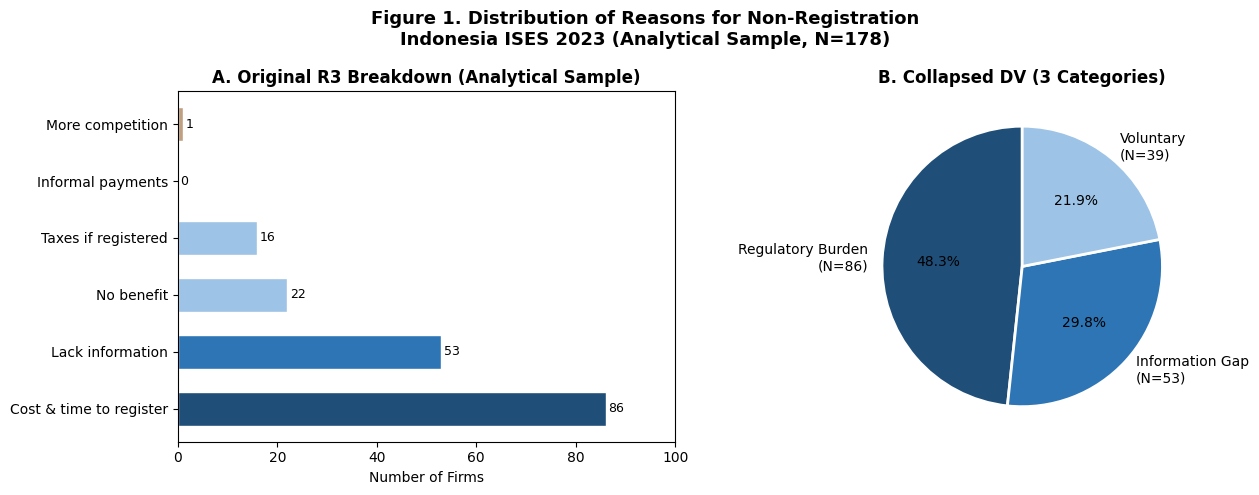

In [8]:
# Attach original r3 codes to df_clean
# (only needed if Section 2.3 was not re-run after the update)
df_clean['r3'] = df['r3'].reset_index(drop=True)[df[
    ['r3_cat','r3','edu','log_workers','log_sales','bank_acc','age','female',
     'sector_manuf','sector_service',
     'city_Surabaya','city_Medan','city_Makassar','city_Denpasar','city_Pontianak']
].notna().all(axis=1).values].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── IMPORTANT: Both panels use df_clean (analytical sample, N=178) ────────────
# This ensures counts are fully consistent between the two panels.
# 'r3' (original codes) was included in df_clean at Section 2.3 for this purpose.

# ── Left panel: original R3 category breakdown within analytical sample ────────
ax = axes[0]
r3_display = {
    1: 'Cost & time to register',
    2: 'Lack information',
    3: 'No benefit',
    4: 'Taxes if registered',
    6: 'Informal payments',
    7: 'More competition',
}
counts = [df_clean['r3'].value_counts().get(k, 0) for k in r3_display]
labels = list(r3_display.values())
colors = ['#1f4e79', '#2e75b6', '#9dc3e6', '#9dc3e6', '#c0a080', '#c0a080']

ax.barh(labels, counts, color=colors, edgecolor='white', height=0.6)
for i, c in enumerate(counts):
    ax.text(c + 0.5, i, str(c), va='center', fontsize=9)
ax.set_xlabel('Number of Firms')
ax.set_title('A. Original R3 Breakdown (Analytical Sample)', fontweight='bold')
ax.set_xlim(0, 100)

# ── Right panel: collapsed 3-category DV — same df_clean ─────────────────────
ax2 = axes[1]
cat3_counts = df_clean['r3_cat'].value_counts().sort_index().values
cat3_labels = [
    f'Regulatory Burden\n(N={cat3_counts[0]})',
    f'Information Gap\n(N={cat3_counts[1]})',
    f'Voluntary\n(N={cat3_counts[2]})'
]

ax2.pie(cat3_counts,
        labels=cat3_labels,
        autopct='%1.1f%%',
        colors=['#1f4e79', '#2e75b6', '#9dc3e6'],
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('B. Collapsed DV (3 Categories)', fontweight='bold')

plt.suptitle(f'Figure 1. Distribution of Reasons for Non-Registration\n'
             f'Indonesia ISES 2023 (Analytical Sample, N={len(df_clean)})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_r3_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.3 Figure 2 — Comparison of IV Between Groups

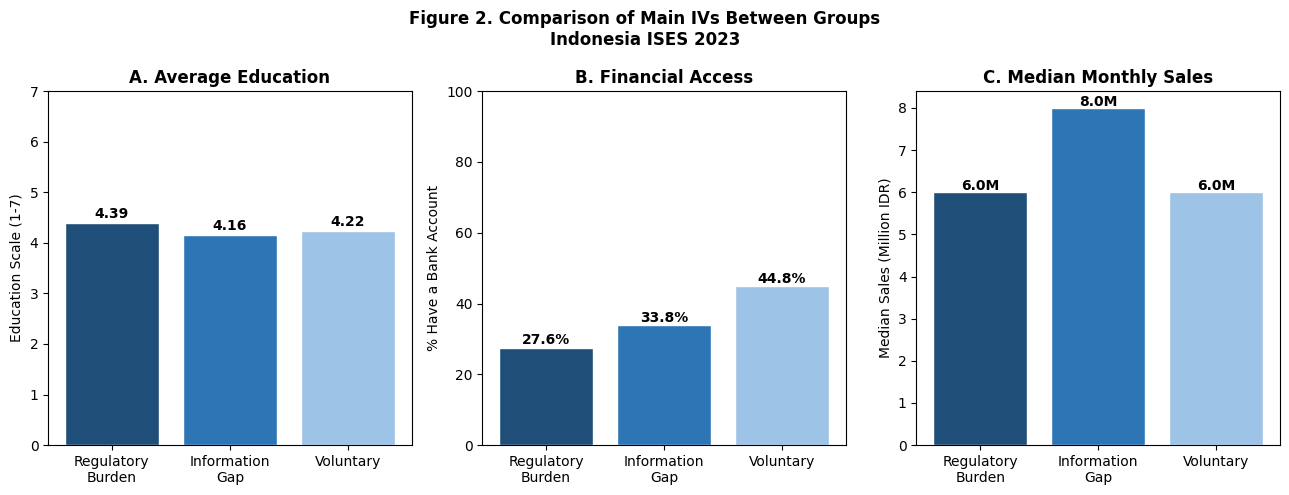

In [9]:
# Build a custom sample for plotting so it doesn't hang on the old df_clean in memory
plot_vars = ['r3_cat', 'edu', 'bank_acc', 'sales']
df_plot = df[['r3_cat', 'edu', 'bank_acc', 'sales']].dropna()

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
grp_names = ['Regulatory\nBurden', 'Information\nGap', 'Voluntary']
colors    = ['#1f4e79', '#2e75b6', '#9dc3e6']

# ── Panel A: Average Education ─────────────────────────────────────────────
means_edu = [df_plot[df_plot['r3_cat'] == g]['edu'].mean() for g in [0, 1, 2]]
axes[0].bar(grp_names, means_edu, color=colors, edgecolor='white')
axes[0].set_ylim(0, 7)
axes[0].set_ylabel('Education Scale (1-7)')
axes[0].set_title('A. Average Education', fontweight='bold')
for i, m in enumerate(means_edu):
    axes[0].text(i, m + 0.1, f'{m:.2f}', ha='center', fontweight='bold')

# ── Panel B: % Have a Bank Account ───────────────────────────────────────────
pct_bank = [df_plot[df_plot['r3_cat'] == g]['bank_acc'].mean() * 100 for g in [0, 1, 2]]
axes[1].bar(grp_names, pct_bank, color=colors, edgecolor='white')
axes[1].set_ylim(0, 100)
axes[1].set_ylabel('% Have a Bank Account')
axes[1].set_title('B. Financial Access', fontweight='bold')
for i, p in enumerate(pct_bank):
    axes[1].text(i, p + 1.0, f'{p:.1f}%', ha='center', fontweight='bold')

# ── Panel C: Median Sales ─────────────────────────────────────────────────
med_sales = [df_plot[df_plot['r3_cat'] == g]['sales'].median() / 1_000_000 for g in [0, 1, 2]]
axes[2].bar(grp_names, med_sales, color=colors, edgecolor='white')
axes[2].set_ylabel('Median Sales (Million IDR)')
axes[2].set_title('C. Median Monthly Sales', fontweight='bold')
for i, m in enumerate(med_sales):
    axes[2].text(i, m + 0.05, f'{m:.1f}M', ha='center', fontweight='bold')

plt.suptitle('Figure 2. Comparison of Main IVs Between Groups\nIndonesia ISES 2023',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_perbandingan_grup.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Multinomial Logistic Regression

**Base outcome = 0 (Regulatory Burden)**

Three nested models:
- **Model 1** — Core IVs only
- **Model 2** — + demographic controls (age, gender)
- **Model 3** — + sector & city fixed effects *(preferred)*

### 4.1 Model Estimation

In [10]:
# ── Model 1: Core IVs ─────────────────────────────────────────────────────────
iv_m1 = ['edu', 'log_workers', 'log_sales', 'bank_acc']
X1 = sm.add_constant(df_clean[iv_m1])
Y  = df_clean['r3_cat']
m1 = MNLogit(Y, X1).fit(method='bfgs', maxiter=500, disp=False)

# ── Model 2: + Demographic Controls ─────────────────────────────────────
iv_m2 = iv_m1 + ['age', 'female']
X2 = sm.add_constant(df_clean[iv_m2])
m2 = MNLogit(Y, X2).fit(method='bfgs', maxiter=500, disp=False)

# ── Model 3: + Sector & City Fixed Effects ──────────────────────────────────
iv_m3 = iv_m2 + ['sector_manuf', 'sector_service',
                  'city_Surabaya', 'city_Medan', 'city_Makassar',
                  'city_Denpasar', 'city_Pontianak']
X3 = sm.add_constant(df_clean[iv_m3])
m3 = MNLogit(Y, X3).fit(method='bfgs', maxiter=500, disp=False)

# ── Summary of fit ─────────────────────────────────────────────────────────────
print(f'{'Model':<10} {'N':>5} {'Log-Lik':>12} {'Pseudo-R²':>12} {'AIC':>10}')
print('-' * 55)
for name, m in [('Model 1', m1), ('Model 2', m2), ('Model 3', m3)]:
    print(f'{name:<10} {int(m.nobs):>5} {m.llf:>12.2f} {m.prsquared:>12.4f} {m.aic:>10.2f}')

Model          N      Log-Lik    Pseudo-R²        AIC
-------------------------------------------------------
Model 1      178      -179.03       0.0374     378.06
Model 2      178      -177.77       0.0441     383.54
Model 3      178      -162.21       0.1278     380.42


### 4.2 Regression Results — Model 3 (Preferred)

In [11]:
# Show full statsmodels output
print(m3.summary())

                          MNLogit Regression Results                          
Dep. Variable:                 r3_cat   No. Observations:                  178
Model:                        MNLogit   Df Residuals:                      150
Method:                           MLE   Df Model:                           26
Date:                Sat, 18 Apr 2026   Pseudo R-squ.:                  0.1278
Time:                        09:54:02   Log-Likelihood:                -162.21
converged:                       True   LL-Null:                       -185.98
Covariance Type:            nonrobust   LLR p-value:                  0.006105
      r3_cat=1       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -2.8110      3.509     -0.801      0.423      -9.688       4.066
edu               -0.3470      0.199     -1.739      0.082      -0.738       0.044
log_workers       -0.4919      0.466

### 4.3 Coefficient Summary Table (Core IVs only)

In [12]:
def sig(p):
    if p < 0.01:  return '***'
    elif p < 0.05: return '**'
    elif p < 0.10: return '*'
    else:          return ''

# Variable labels
var_label = {
    'edu'         : 'Education (1–7)',
    'log_workers' : 'Log(Workers)',
    'log_sales'   : 'Log(Sales)',
    'bank_acc'    : 'Has Bank Account',
}

rows = []
for var, label in var_label.items():
    row = {'Variable': label}
    for model_name, model in [('Model 1', m1), ('Model 2', m2), ('Model 3', m3)]:
        for j, outcome in enumerate(['Info Gap (j=1)', 'Voluntary (j=2)']):
            coef = model.params.loc[var].iloc[j]
            se   = model.bse.loc[var].iloc[j]
            pv   = model.pvalues.loc[var].iloc[j]
            col  = f'{model_name} — {outcome}'
            row[col] = f'{coef:.3f}{sig(pv)} ({se:.3f})'
    rows.append(row)

tbl_reg = pd.DataFrame(rows).set_index('Variable')

print('Table 2. Multinomial Logit — Core IVs Coefficients')
print('Base outcome: Regulatory Burden | Format: Coef*** (SE)')
print('*** p<0.01  ** p<0.05  * p<0.10\n')
pd.set_option('display.max_colwidth', 30)
display(tbl_reg)

Table 2. Multinomial Logit — Core IVs Coefficients
Base outcome: Regulatory Burden | Format: Coef*** (SE)
*** p<0.01  ** p<0.05  * p<0.10



,Model 1 — Info Gap (j=1),Model 1 — Voluntary (j=2),Model 2 — Info Gap (j=1),Model 2 — Voluntary (j=2),Model 3 — Info Gap (j=1),Model 3 — Voluntary (j=2)
Variable,,,,,,
Education (1–7),-0.205 (0.171),-0.416** (0.200),-0.201 (0.177),-0.382* (0.204),-0.347* (0.199),-0.509** (0.231)
Log(Workers),-0.097 (0.399),0.523 (0.427),-0.113 (0.404),0.558 (0.435),-0.492 (0.466),0.339 (0.503)
Log(Sales),0.223 (0.200),-0.264 (0.198),0.260 (0.204),-0.275 (0.204),0.179 (0.224),-0.227 (0.224)
Has Bank Account,0.174 (0.401),0.863* (0.444),0.153 (0.405),0.883** (0.448),0.199 (0.434),0.766 (0.475)


### 4.4 Average Marginal Effects (Model 3)

In [13]:
ame = m3.get_margeff(at='overall')
print('Average Marginal Effects — Model 3')
print(ame.summary())

# Build a publication-style AME table (same style as multinomial logit table)
var_label_ame = {
    'edu': 'Education (1–7)',
    'log_workers': 'Log(Workers)',
    'log_sales': 'Log(Sales)',
    'bank_acc': 'Has Bank Account',
    'age': 'Owner Age',
    'female': 'Owner Female',
    'sector_manuf': 'Sector: Manufacturing',
    'sector_service': 'Sector: Service',
    'city_Surabaya': 'City: Surabaya',
    'city_Medan': 'City: Medan',
    'city_Makassar': 'City: Makassar',
    'city_Denpasar': 'City: Denpasar',
    'city_Pontianak': 'City: Pontianak',
}

# Number of AME outcome columns can vary by statsmodels version/specification
n_outcomes = ame.margeff.shape[1] if np.ndim(ame.margeff) > 1 else 1

outcome_labels_full = [
    'Regulatory Burden (j=0)',
    'Information Gap (j=1)',
    'Voluntary (j=2)',
]
outcome_labels = outcome_labels_full[:n_outcomes]
if len(outcome_labels) < n_outcomes:
    outcome_labels += [f'Outcome {k+1}' for k in range(len(outcome_labels), n_outcomes)]

# Match AME rows to regressors (margeff excludes constant)
ame_vars = list(m3.model.exog_names)
if 'const' in ame_vars and len(ame_vars) - 1 == ame.margeff.shape[0]:
    ame_vars.remove('const')
if len(ame_vars) != ame.margeff.shape[0]:
    ame_vars = ame_vars[:ame.margeff.shape[0]]

rows_fmt = []
rows_num = []
ci = np.asarray(ame.conf_int())

# Helper: safely read [i,j] from arrays that may be 1D/2D

def get_ij(arr, i, j):
    a = np.asarray(arr)
    if a.ndim == 1:
        return a[i]
    return a[i, j]

# Helper: safely read CI regardless of returned shape

def get_ci_ij(ci_arr, i, j, n_j):
    c = np.asarray(ci_arr)

    # Case A: (n_vars, n_outcomes, 2)
    if c.ndim == 3 and c.shape[0] > i and c.shape[1] > j and c.shape[2] == 2:
        return c[i, j, 0], c[i, j, 1]

    # Case B: (n_vars, 2, n_outcomes)
    if c.ndim == 3 and c.shape[0] > i and c.shape[1] == 2 and c.shape[2] > j:
        return c[i, 0, j], c[i, 1, j]

    # Case C: flattened (n_vars*n_outcomes, 2)
    if c.ndim == 2 and c.shape[1] == 2 and c.shape[0] == len(ame_vars) * n_j:
        idx = i * n_j + j
        return c[idx, 0], c[idx, 1]

    # Case D: per-variable only (n_vars, 2)
    if c.ndim == 2 and c.shape[1] == 2 and c.shape[0] > i:
        return c[i, 0], c[i, 1]

    return np.nan, np.nan

for i, var in enumerate(ame_vars):
    label = var_label_ame.get(var, var)
    row = {'Variable': label}

    for j, out in enumerate(outcome_labels):
        dydx = get_ij(ame.margeff, i, j)
        se = get_ij(ame.margeff_se, i, j)
        pval = get_ij(ame.pvalues, i, j)
        zval = get_ij(ame.tvalues, i, j)
        ci_low, ci_high = get_ci_ij(ci, i, j, n_outcomes)

        row[out] = f'{dydx:.4f}{sig(pval)} ({se:.4f})'
        rows_num.append({
            'Variable': label,
            'Outcome': out,
            'dy_dx': dydx,
            'std_err': se,
            'z': zval,
            'p_value': pval,
            'ci_low': ci_low,
            'ci_high': ci_high,
        })

    rows_fmt.append(row)

tbl_ame_m3 = pd.DataFrame(rows_fmt).set_index('Variable')
tbl_ame_m3_num = pd.DataFrame(rows_num)

print('\nTable 3. Average Marginal Effects (AME) — Model 3')
print('Format: dy/dx*** (SE) | *** p<0.01  ** p<0.05  * p<0.10\n')
display(tbl_ame_m3)

Average Marginal Effects — Model 3
       MNLogit Marginal Effects      
Dep. Variable:                 r3_cat
Method:                          dydx
At:                           overall
      r3_cat=0      dy/dx    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
edu                0.0857      0.034      2.495      0.013       0.018       0.153
log_workers        0.0323      0.083      0.391      0.696      -0.130       0.194
log_sales         -0.0030      0.038     -0.079      0.937      -0.078       0.072
bank_acc          -0.0889      0.077     -1.148      0.251      -0.241       0.063
age               -0.0019      0.004     -0.509      0.611      -0.009       0.005
female            -0.1055      0.074     -1.429      0.153      -0.250       0.039
sector_manuf       0.0942      0.196      0.480      0.631      -0.291       0.479
sector_service     0.0241      0.101      0.239      0.811      -0

,Regulatory Burden (j=0),Information Gap (j=1),Voluntary (j=2)
Variable,,,
Education (1–7),0.0857** (0.0343),-0.0325 (0.0339),-0.0531* (0.0308)
Log(Workers),0.0323 (0.0826),-0.1138 (0.0790),0.0815 (0.0676)
Log(Sales),-0.0030 (0.0383),0.0480 (0.0385),-0.0450 (0.0303)
Has Bank Account,-0.0889 (0.0774),-0.0115 (0.0737),0.1004 (0.0630)
Owner Age,-0.0019 (0.0037),-0.0015 (0.0037),0.0034 (0.0032)
Owner Female,-0.1055 (0.0738),0.0771 (0.0707),0.0284 (0.0620)
Sector: Manufacturing,0.0942 (0.1963),-0.0280 (0.2181),-0.0661 (0.1873)
Sector: Service,0.0241 (0.1006),0.0710 (0.0950),-0.0951 (0.0946)
City: Surabaya,-0.2824*** (0.0759),0.1292* (0.0778),0.1532** (0.0709)


### 4.5 Figure 3 — Predicted Probabilities by Education

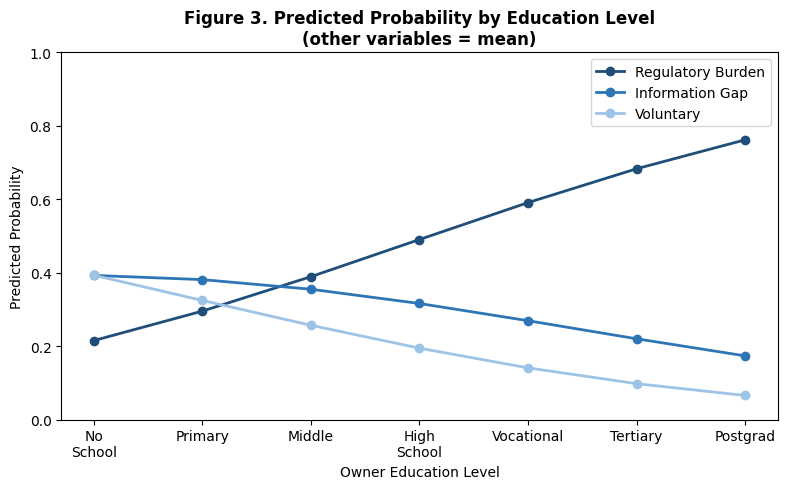

In [14]:
# Predicted probabilities by education level
means = df_clean[iv_m3].mean()

edu_values = [1, 2, 3, 4, 5, 6, 7]
pred_list  = []

for e in edu_values:
    row = means.copy()
    row['edu'] = e
    row_with_const = pd.concat([pd.Series({'const': 1.0}), row])
    pred = m3.predict(row_with_const.values.reshape(1, -1))
    pred_list.append(pred[0])

pred_df = pd.DataFrame(pred_list,
                        columns=['Regulatory Burden', 'Information Gap', 'Voluntary'],
                        index=edu_values)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
edu_xlabels = ['No\nSchool', 'Primary', 'Middle', 'High\nSchool', 'Vocational', 'Tertiary', 'Postgrad']

for col, color in zip(pred_df.columns, ['#1f4e79', '#2e75b6', '#9dc3e6']):
    ax.plot(edu_values, pred_df[col], marker='o', color=color, linewidth=2, label=col)

ax.set_xticks(edu_values)
ax.set_xticklabels(edu_xlabels)
ax.set_ylabel('Predicted Probability')
ax.set_xlabel('Owner Education Level')
ax.set_title('Figure 3. Predicted Probability by Education Level\n(other variables = mean)',
             fontweight='bold')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('fig3_pred_prob_edu.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Export Results to Excel

In [15]:
with pd.ExcelWriter('hasil_regresi.xlsx', engine='openpyxl') as writer:
    tbl_desc.to_excel(writer, sheet_name='Tabel1_Deskriptif')
    tbl_reg.to_excel(writer,  sheet_name='Tabel2_Regresi')
    tbl_ame_m3.to_excel(writer, sheet_name='Tabel3_AME_Model3')
    tbl_ame_m3_num.to_excel(writer, sheet_name='Tabel3_AME_Raw', index=False)

print('File saved: hasil_regresi.xlsx')
print('Sheets: Tabel1_Deskriptif, Tabel2_Regresi, Tabel3_AME_Model3, Tabel3_AME_Raw')
print('Figures: fig1, fig2, fig3 (.png)')

File saved: hasil_regresi.xlsx
Sheets: Tabel1_Deskriptif, Tabel2_Regresi, Tabel3_AME_Model3, Tabel3_AME_Raw
Figures: fig1, fig2, fig3 (.png)
